<a href="https://colab.research.google.com/github/meghana2343/research-methods/blob/main/Comparing%20a%20Fine-Tuned%20DistilBERT%20Model%20with%20a%20TF-IDF%20Baseline%20for%20News%20Topic%20Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparing a Fine-Tuned DistilBERT Model with a TF-IDF Baseline for News Topic Classification
 RESEARCH METHODS MODULE: LLM ASSIGNMENT



## import and insatll libraries required and dependencies

In [ ]:
!pip -q install "transformers>=4.46,<5" "datasets>=2.19" "scikit-learn>=1.3" \
    "matplotlib>=3.7" "seaborn>=0.13" "accelerate>=0.30" "tabulate>=0.9" "statsmodels>=0.14"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 21.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


## 1. Imports and reproducibility

In [ ]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

from datasets import load_dataset, Dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)


def show_table(frame, floatfmt=".4f"):
    print(tabulate(frame, headers="keys", tablefmt="github", floatfmt=floatfmt))


def lock_all_randomness(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


HARDWARE = "cuda" if torch.cuda.is_available() else "cpu"
print("compute device:", HARDWARE)

compute device: cuda


## 2. Settings

Every tunable used anywhere in this notebook lives in one dictionary, so nothing downstream invents a hyperparameter on the fly.

In [ ]:
SETTINGS = {
    # --- data ---
    "hub_id": "ag_news",
    "text_col": "text",
    "label_col": "label",
    "n_labels": 4,
    "label_names": ["World", "Sports", "Business", "Sci/Tech"],
    "train_subsample": 20000,   # set to None to use the full 120k rows
    "val_fraction": 0.1,
    # --- transformer ---
    "checkpoint": "distilbert-base-uncased",
    "max_length": 64,           # justified later from measured token-length percentiles
    "batch_size": 32,
    "learning_rate": 2e-5,
    "epochs": 3,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    # --- scoring ---
    "averaging": "macro",       # each of the 4 classes weighted equally
    # --- reproducibility ---
    "seed": 23,
}

lock_all_randomness(SETTINGS["seed"])
sns.set_theme(style="whitegrid", palette="viridis")

OUT = Path("outputs")
FIG_DIR, TAB_DIR, CKPT_DIR = OUT / "figures", OUT / "tables", OUT / "models"
for d in (FIG_DIR, TAB_DIR, CKPT_DIR):
    d.mkdir(parents=True, exist_ok=True)

show_table(pd.Series(SETTINGS, name="value").to_frame(), floatfmt=".5g")

|                 | value                                       |
|-----------------|---------------------------------------------|
| hub_id          | ag_news                                     |
| text_col        | text                                        |
| label_col       | label                                       |
| n_labels        | 4                                           |
| label_names     | ['World', 'Sports', 'Business', 'Sci/Tech'] |
| train_subsample | 20000                                       |
| val_fraction    | 0.1                                         |
| checkpoint      | distilbert-base-uncased                     |
| max_length      | 64                                          |
| batch_size      | 32                                          |
| learning_rate   | 2e-05                                       |
| epochs          | 3                                           |
| weight_decay    | 0.01                                        |
| warmup_r

## 3. Load data

AG News ships with an official train/test split. A stratified validation split is carved out of (a subsample of) train; the test split is untouched until the single evaluation pass later.

In [ ]:
hub_data = load_dataset(SETTINGS["hub_id"])
LABELS = SETTINGS["label_names"]
print(hub_data)

full_train = hub_data["train"].to_pandas()
test_frame = hub_data["test"].to_pandas()

if SETTINGS["train_subsample"]:
    full_train = (
        full_train.groupby(SETTINGS["label_col"], group_keys=False)
        .apply(lambda g: g.sample(
            n=min(len(g), SETTINGS["train_subsample"] // SETTINGS["n_labels"]),
            random_state=SETTINGS["seed"],
        ))
        .reset_index(drop=True)
    )

val_frame = (
    full_train.groupby(SETTINGS["label_col"], group_keys=False)
    .apply(lambda g: g.sample(frac=SETTINGS["val_fraction"], random_state=SETTINGS["seed"]))
)
train_frame = full_train.drop(val_frame.index).reset_index(drop=True)
val_frame = val_frame.reset_index(drop=True)

print(f"rows -> train {len(train_frame):,} | val {len(val_frame):,} | test {len(test_frame):,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
rows -> train 18,000 | val 2,000 | test 7,600


/tmp/ipykernel_591/1868244682.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(
/tmp/ipykernel_591/1868244682.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=SETTINGS["val_fraction"], random_state=SETTINGS["seed"]))


## 4. Data quality audit and leakage check

Check for nulls, blanks, duplicate texts, and bad label codes; then remove duplicate/leaking rows from train only. Validation and test are never altered.

In [ ]:
def audit_split(frame, name):
    nulls = int(frame[SETTINGS["text_col"]].isna().sum())
    blanks = int((frame[SETTINGS["text_col"]].str.strip() == "").sum())
    dupes = int(frame[SETTINGS["text_col"]].duplicated().sum())
    codes = sorted(frame[SETTINGS["label_col"]].unique().tolist())
    assert nulls == 0 and blanks == 0, f"unusable rows in {name}"
    return {"split": name, "nulls": nulls, "blanks": blanks,
            "dup_texts": dupes, "label_codes": str(codes)}


audit_rows = [audit_split(f, n) for n, f in
              [("train", train_frame), ("validation", val_frame), ("test", test_frame)]]
show_table(pd.DataFrame(audit_rows).set_index("split"), floatfmt="g")

before = len(train_frame)
train_frame = train_frame.drop_duplicates(subset=SETTINGS["text_col"]).reset_index(drop=True)
print(f"removed {before - len(train_frame)} duplicate train rows -> {len(train_frame):,} left")

held_out = set(val_frame[SETTINGS["text_col"]]) | set(test_frame[SETTINGS["text_col"]])
before = len(train_frame)
train_frame = train_frame[~train_frame[SETTINGS["text_col"]].isin(held_out)].reset_index(drop=True)
print(f"removed {before - len(train_frame)} train rows leaking into val/test")

| split      |   nulls |   blanks |   dup_texts | label_codes   |
|------------|---------|----------|-------------|---------------|
| train      |       0 |        0 |           0 | [0, 1, 2, 3]  |
| validation |       0 |        0 |           0 | [0, 1, 2, 3]  |
| test       |       0 |        0 |           0 | [0, 1, 2, 3]  |
removed 0 duplicate train rows -> 18,000 left
removed 0 train rows leaking into val/test


## 5. Exploratory data analysis

Two things matter before modelling: how balanced the four topics are, and how long the articles are (which will justify `max_length` later).

| topic    |   articles |   share_% |
|----------|------------|-----------|
| World    |    4500.00 |     25.00 |
| Sports   |    4500.00 |     25.00 |
| Business |    4500.00 |     25.00 |
| Sci/Tech |    4500.00 |     25.00 |

words-per-article summary:
count    18000.0
mean        38.0
std         10.3
min          8.0
25%         32.0
50%         37.0
75%         43.0
max        146.0


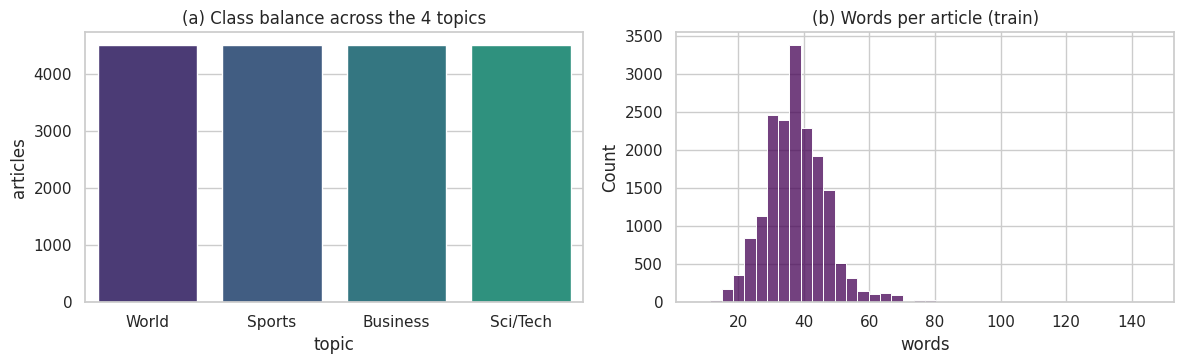

In [ ]:
class_counts = train_frame[SETTINGS["label_col"]].value_counts().sort_index()
balance = pd.DataFrame({
    "topic": LABELS,
    "articles": class_counts.values,
    "share_%": (100 * class_counts.values / class_counts.sum()).round(2),
})
show_table(balance.set_index("topic"), floatfmt=".2f")

words_per_row = train_frame[SETTINGS["text_col"]].str.split().str.len()
print("\nwords-per-article summary:")
print(words_per_row.describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sns.barplot(data=balance, x="topic", y="articles", hue="topic", legend=False, ax=axes[0])
axes[0].set_title("(a) Class balance across the 4 topics")
sns.histplot(words_per_row, bins=40, ax=axes[1], color="#440154")
axes[1].set_title("(b) Words per article (train)")
axes[1].set_xlabel("words")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_balance_and_length.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Shared scoring function

One function grades both the baseline and BERT, using the same macro-averaging, so the head-to-head comparison cannot drift.

In [ ]:
def grade(y_true, y_pred):
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=SETTINGS["averaging"], zero_division=0
    )
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
    }

## 7. Baseline: TF-IDF + LinearSVC

A `LinearSVC` over TF-IDF uni- and bi-grams is a strong, hard-to-beat floor for short text. Regularisation strength `C` is chosen on **validation**; **test** is graded once, at the end, through the same `grade()` helper BERT will use. Fit/predict times are captured for the later efficiency comparison.

In [ ]:
import time

def make_svm(c_value):
    return Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
        ("svm", LinearSVC(C=c_value, class_weight="balanced", random_state=SETTINGS["seed"])),
    ])


c_candidates = [0.1, 0.5, 1.0, 2.0]
sweep = {}
for c_value in c_candidates:
    pipe = make_svm(c_value)
    pipe.fit(train_frame[SETTINGS["text_col"]], train_frame[SETTINGS["label_col"]])
    sweep[c_value] = grade(
        val_frame[SETTINGS["label_col"]], pipe.predict(val_frame[SETTINGS["text_col"]])
    )["f1"]

sweep_frame = pd.DataFrame({"C": list(sweep), "val_macro_f1": list(sweep.values())})
show_table(sweep_frame.set_index("C"))

chosen_c = max(sweep, key=sweep.get)
print("chosen C:", chosen_c)

baseline_clf = make_svm(chosen_c)

svm_train_start = time.time()
baseline_clf.fit(train_frame[SETTINGS["text_col"]], train_frame[SETTINGS["label_col"]])
svm_train_seconds = time.time() - svm_train_start

svm_predict_start = time.time()
svm_test_pred = baseline_clf.predict(test_frame[SETTINGS["text_col"]])
svm_predict_seconds = time.time() - svm_predict_start

baseline_scores = grade(test_frame[SETTINGS["label_col"]], svm_test_pred)
print("TF-IDF + LinearSVC (test, macro):", {k: round(v, 4) for k, v in baseline_scores.items()})
print(f"train time: {svm_train_seconds:.2f}s | predict time on {len(test_frame):,} rows: {svm_predict_seconds:.2f}s")

|      C |   val_macro_f1 |
|--------|----------------|
| 0.1000 |         0.8989 |
| 0.5000 |         0.9040 |
| 1.0000 |         0.9070 |
| 2.0000 |         0.9065 |
chosen C: 1.0
TF-IDF + LinearSVC (test, macro): {'accuracy': 0.9014, 'precision': 0.9009, 'recall': 0.9014, 'f1': 0.901}
train time: 1.87s | predict time on 7,600 rows: 0.43s


## 8. How many tokens do we need?

Before fixing `max_length`, measure the *real* WordPiece token lengths of the training articles and pick a value from the percentiles rather than from habit.

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

|   percentile |   tokens |
|--------------|----------|
|           50 |  51.0000 |
|           90 |  70.0000 |
|           95 |  83.0000 |
|           99 | 126.0000 |
|          100 | 368.0000 |
articles longer than max_length=64: 15.36%


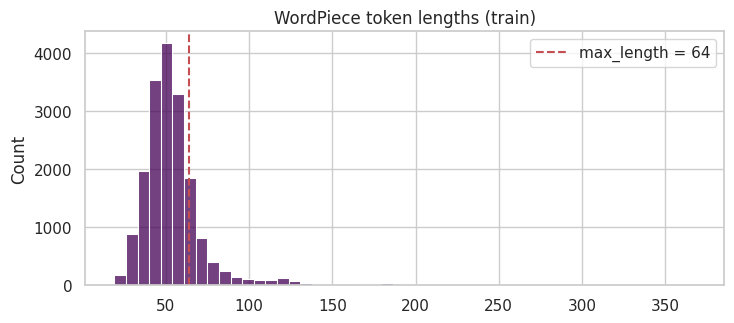

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(SETTINGS["checkpoint"])

encoded_lengths = np.array([
    len(ids) for ids in
    tokenizer(train_frame[SETTINGS["text_col"]].tolist(), truncation=False)["input_ids"]
])
pct = {p: int(np.percentile(encoded_lengths, p)) for p in (50, 90, 95, 99, 100)}
truncated_share = float((encoded_lengths > SETTINGS["max_length"]).mean() * 100)

show_table(pd.DataFrame({"percentile": list(pct), "tokens": list(pct.values())}).set_index("percentile"))
max_len = SETTINGS["max_length"]
print(f"articles longer than max_length={max_len}: {truncated_share:.2f}%")

fig, ax = plt.subplots(figsize=(7.5, 3.4))
sns.histplot(encoded_lengths, bins=50, ax=ax, color="#440154")
ax.axvline(max_len, color="#c44e52", linestyle="--",
           label=f"max_length = {max_len}")
ax.set_title("WordPiece token lengths (train)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "token_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Fine-tune DistilBERT initialization



In [ ]:
def to_hf_dataset(frame):
    return Dataset.from_pandas(frame[[SETTINGS["text_col"], SETTINGS["label_col"]]]
                                .rename(columns={SETTINGS["label_col"]: "labels"}))

train_ds = to_hf_dataset(train_frame)
val_ds = to_hf_dataset(val_frame)
test_ds = to_hf_dataset(test_frame)


def tokenize_fn(batch):
    return tokenizer(batch[SETTINGS["text_col"]], truncation=True, max_length=SETTINGS["max_length"])


train_ds = train_ds.map(tokenize_fn, batched=True).remove_columns([SETTINGS["text_col"]])
val_ds = val_ds.map(tokenize_fn, batched=True).remove_columns([SETTINGS["text_col"]])
test_ds = test_ds.map(tokenize_fn, batched=True).remove_columns([SETTINGS["text_col"]])

collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(
    SETTINGS["checkpoint"], num_labels=SETTINGS["n_labels"]
)
model.to(HARDWARE)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return grade(labels, preds)


training_args = TrainingArguments(
    output_dir=str(CKPT_DIR),
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=SETTINGS["learning_rate"],
    per_device_train_batch_size=SETTINGS["batch_size"],
    per_device_eval_batch_size=64,
    num_train_epochs=SETTINGS["epochs"],
    weight_decay=SETTINGS["weight_decay"],
    warmup_ratio=SETTINGS["warmup_ratio"],
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none",
    seed=SETTINGS["seed"],
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

bert_train_start = time.time()
train_result = trainer.train()
bert_train_seconds = time.time() - bert_train_start
print(f"fine-tuning time: {bert_train_seconds:.1f}s ({bert_train_seconds/60:.1f} min)")

Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.271300,0.260880,0.913500,0.915174,0.913500,0.912818
2,0.210300,0.245085,0.917500,0.916972,0.917500,0.917150
3,0.133900,0.243420,0.919500,0.919524,0.919500,0.919419


fine-tuning time: 325.3s (5.4 min)


## 10. The single look at the test set

Test is graded exactly once, here, using the same `grade()` helper as the baseline.

In [ ]:
bert_predict_start = time.time()
test_output = trainer.predict(test_ds)
bert_predict_seconds = time.time() - bert_predict_start

bert_test_pred = np.argmax(test_output.predictions, axis=-1)
bert_scores = grade(test_frame[SETTINGS["label_col"]], bert_test_pred)
print(f"predict time on {len(test_frame):,} rows: {bert_predict_seconds:.2f}s")
print("Fine-tuned DistilBERT (test, macro):", {k: round(v, 4) for k, v in bert_scores.items()})
print("\nFull classification report:")
print(classification_report(test_frame[SETTINGS["label_col"]], bert_test_pred, target_names=LABELS))

trainer.save_model(str(CKPT_DIR / "final"))
tokenizer.save_pretrained(str(CKPT_DIR / "final"))

predict time on 7,600 rows: 12.96s
Fine-tuned DistilBERT (test, macro): {'accuracy': 0.922, 'precision': 0.9221, 'recall': 0.922, 'f1': 0.922}

Full classification report:
              precision    recall  f1-score   support

       World       0.94      0.91      0.93      1900
      Sports       0.97      0.98      0.98      1900
    Business       0.89      0.88      0.89      1900
    Sci/Tech       0.89      0.91      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



('outputs/models/final/tokenizer_config.json',
 'outputs/models/final/special_tokens_map.json',
 'outputs/models/final/vocab.txt',
 'outputs/models/final/added_tokens.json',
 'outputs/models/final/tokenizer.json')

## 11. Does the transformer beat the baseline?

Head-to-head comparison table and chart.

| Model                         |   Accuracy |   Precision (macro) |   Recall (macro) |   F1 (macro) |
|-------------------------------|------------|---------------------|------------------|--------------|
| TF-IDF + LinearSVC (baseline) |     0.9014 |              0.9009 |           0.9014 |       0.9010 |
| Fine-tuned DistilBERT (ours)  |     0.9220 |              0.9221 |           0.9220 |       0.9220 |


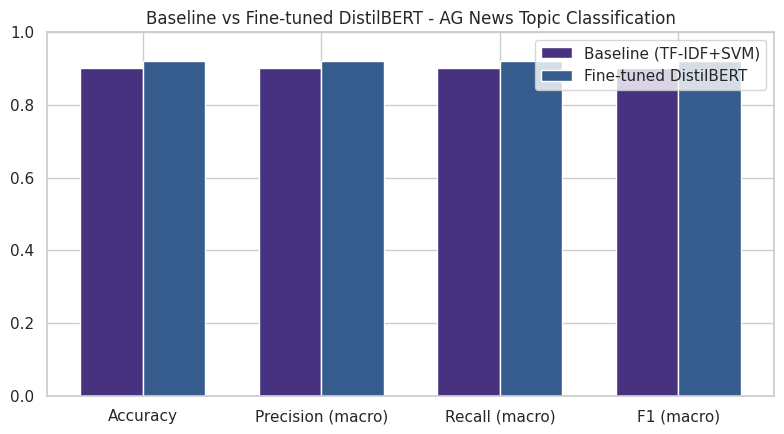

In [ ]:
comparison = pd.DataFrame({
    "Model": ["TF-IDF + LinearSVC (baseline)", "Fine-tuned DistilBERT (ours)"],
    "Accuracy": [baseline_scores["accuracy"], bert_scores["accuracy"]],
    "Precision (macro)": [baseline_scores["precision"], bert_scores["precision"]],
    "Recall (macro)": [baseline_scores["recall"], bert_scores["recall"]],
    "F1 (macro)": [baseline_scores["f1"], bert_scores["f1"]],
})
show_table(comparison.set_index("Model"))
comparison.to_csv(TAB_DIR / "model_comparison.csv", index=False)

metrics = ["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)"]
x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width / 2, comparison.iloc[0, 1:], width, label="Baseline (TF-IDF+SVM)")
ax.bar(x + width / 2, comparison.iloc[1, 1:], width, label="Fine-tuned DistilBERT")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_title("Baseline vs Fine-tuned DistilBERT - AG News Topic Classification")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "model_comparison_chart.png", dpi=150)
plt.show()

## 12. Who does it get wrong?

Normalised confusion matrices for both models, side by side, to see which topic pairs are hardest to separate.

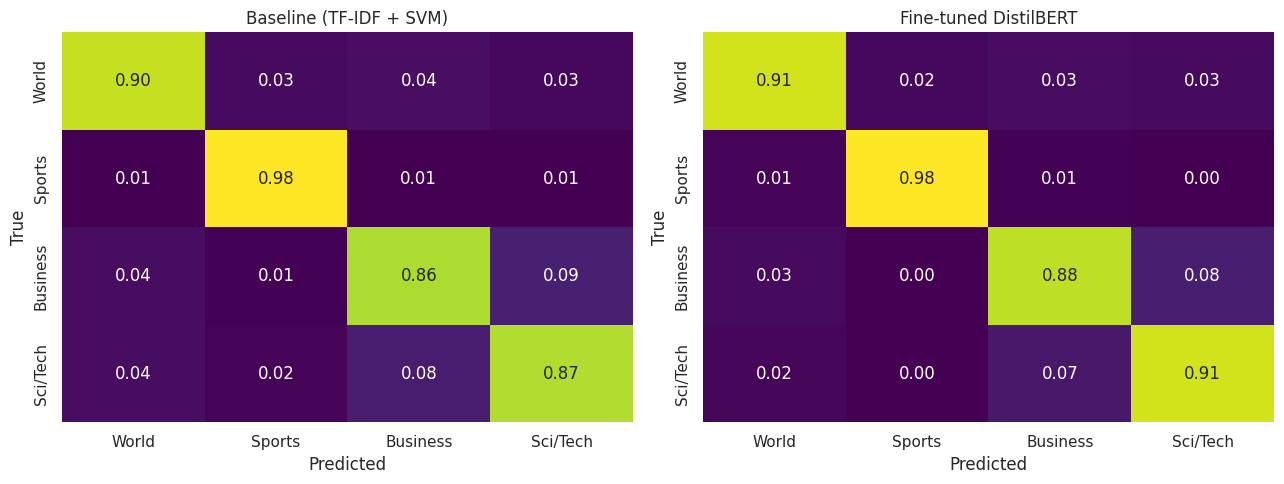


Done. Artefacts saved under ./outputs/{figures,tables,models}


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, preds, title in [
    (axes[0], svm_test_pred, "Baseline (TF-IDF + SVM)"),
    (axes[1], bert_test_pred, "Fine-tuned DistilBERT"),
]:
    cm = confusion_matrix(test_frame[SETTINGS["label_col"]], preds, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="viridis", xticklabels=LABELS,
                yticklabels=LABELS, ax=ax, cbar=False)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nDone. Artefacts saved under ./outputs/{figures,tables,models}")

## 13. Learning curves



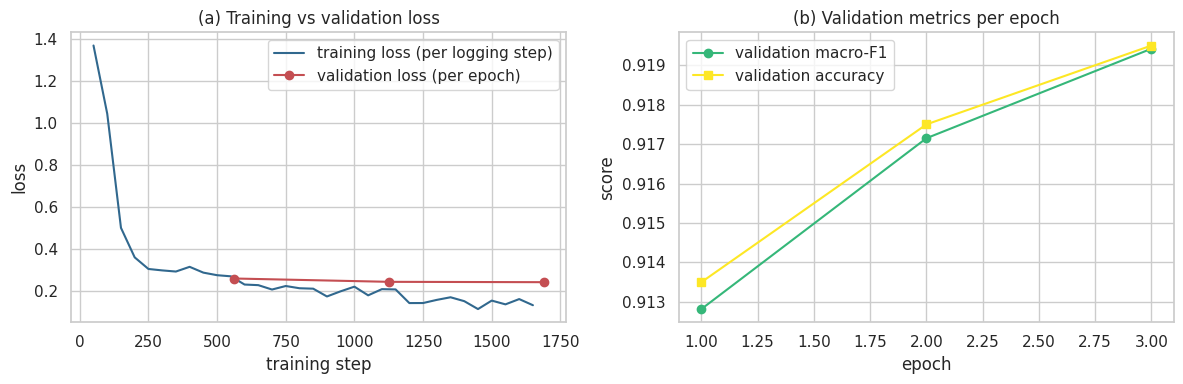

|    |   epoch |   eval_loss |   eval_accuracy |   eval_precision |   eval_recall |   eval_f1 |
|----|---------|-------------|-----------------|------------------|---------------|-----------|
|  0 |  1.0000 |      0.2609 |          0.9135 |           0.9152 |        0.9135 |    0.9128 |
|  1 |  2.0000 |      0.2451 |          0.9175 |           0.9170 |        0.9175 |    0.9171 |
|  2 |  3.0000 |      0.2434 |          0.9195 |           0.9195 |        0.9195 |    0.9194 |


In [ ]:
log_history = pd.DataFrame(trainer.state.log_history)

train_loss = log_history.dropna(subset=["loss"])[["step", "loss"]] if "loss" in log_history else pd.DataFrame()
eval_rows = log_history.dropna(subset=["eval_loss"]) if "eval_loss" in log_history else pd.DataFrame()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if not train_loss.empty:
    axes[0].plot(train_loss["step"], train_loss["loss"], color="#31688e", label="training loss (per logging step)")
if not eval_rows.empty and "epoch" in eval_rows:
    axes[0].plot(eval_rows["step"], eval_rows["eval_loss"], marker="o", color="#c44e52", label="validation loss (per epoch)")
axes[0].set_xlabel("training step")
axes[0].set_ylabel("loss")
axes[0].set_title("(a) Training vs validation loss")
axes[0].legend()

if not eval_rows.empty and "eval_f1" in eval_rows:
    axes[1].plot(eval_rows["epoch"], eval_rows["eval_f1"], marker="o", color="#35b779", label="validation macro-F1")
if not eval_rows.empty and "eval_accuracy" in eval_rows:
    axes[1].plot(eval_rows["epoch"], eval_rows["eval_accuracy"], marker="s", color="#fde725", label="validation accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("score")
axes[1].set_title("(b) Validation metrics per epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

show_table(eval_rows[["epoch", "eval_loss", "eval_accuracy", "eval_precision", "eval_recall", "eval_f1"]].reset_index(drop=True))

## 14. Per-class metrics: baseline vs fine-tuned DistilBERT

This breaks precision/recall/F1 down by topic for both models side by side.

|                                       |   precision |   recall |     f1 |   support |
|---------------------------------------|-------------|----------|--------|-----------|
| ('World', 'Baseline (SVM)')           |      0.9166 |   0.8968 | 0.9066 | 1900.0000 |
| ('Sports', 'Baseline (SVM)')          |      0.9405 |   0.9821 | 0.9609 | 1900.0000 |
| ('Business', 'Baseline (SVM)')        |      0.8715 |   0.8600 | 0.8657 | 1900.0000 |
| ('Sci/Tech', 'Baseline (SVM)')        |      0.8751 |   0.8668 | 0.8710 | 1900.0000 |
| ('World', 'Fine-tuned DistilBERT')    |      0.9374 |   0.9142 | 0.9257 | 1900.0000 |
| ('Sports', 'Fine-tuned DistilBERT')   |      0.9718 |   0.9800 | 0.9759 | 1900.0000 |
| ('Business', 'Fine-tuned DistilBERT') |      0.8910 |   0.8816 | 0.8862 | 1900.0000 |
| ('Sci/Tech', 'Fine-tuned DistilBERT') |      0.8883 |   0.9121 | 0.9000 | 1900.0000 |


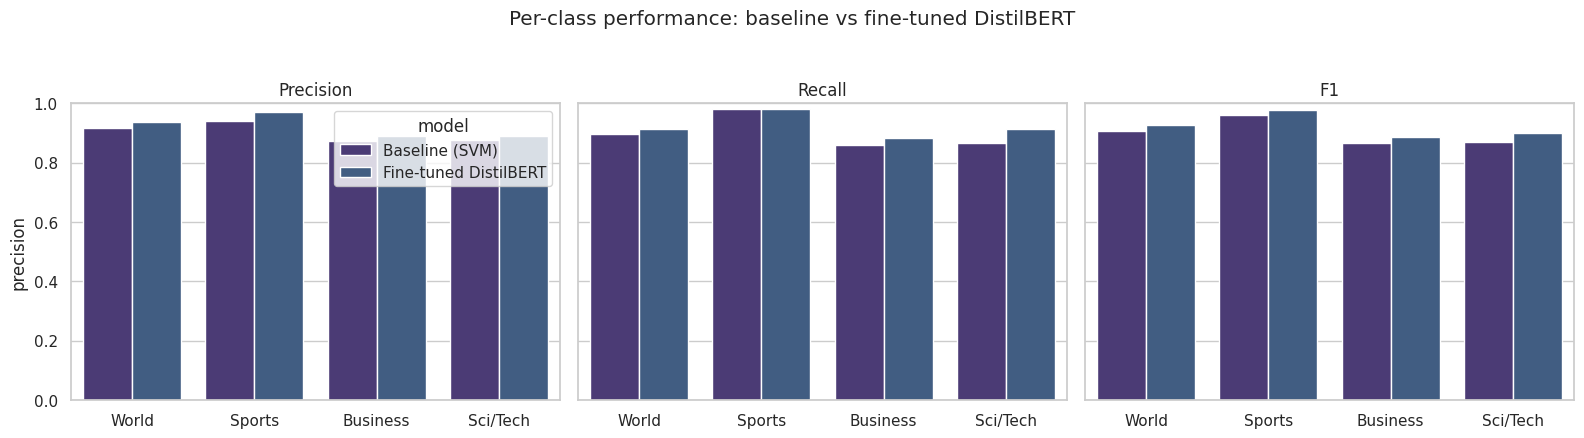

In [ ]:
def per_class_frame(y_true, y_pred, model_name):
    p, r, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=range(SETTINGS["n_labels"]), zero_division=0)
    return pd.DataFrame({
        "topic": LABELS,
        "model": model_name,
        "precision": p,
        "recall": r,
        "f1": f1,
        "support": support,
    })

per_class = pd.concat([
    per_class_frame(test_frame[SETTINGS["label_col"]], svm_test_pred, "Baseline (SVM)"),
    per_class_frame(test_frame[SETTINGS["label_col"]], bert_test_pred, "Fine-tuned DistilBERT"),
], ignore_index=True)

show_table(per_class.set_index(["topic", "model"]))
per_class.to_csv(TAB_DIR / "per_class_metrics.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for ax, metric in zip(axes, ["precision", "recall", "f1"]):
    sns.barplot(data=per_class, x="topic", y=metric, hue="model", ax=ax)
    ax.set_title(metric.capitalize())
    ax.set_ylim(0, 1)
    ax.set_xlabel("")
    if ax is not axes[0]:
        ax.legend_.remove() if ax.legend_ else None
fig.suptitle("Per-class performance: baseline vs fine-tuned DistilBERT", y=1.04)
plt.tight_layout()
plt.savefig(FIG_DIR / "per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

## 15. ROC-AUC curves (one-vs-rest)

ROC-AUC gives a threshold-independent view of separability per class. `LinearSVC` has no `predict_proba`, so its (uncalibrated) decision-function scores are used for ranking, which is valid for ROC/AUC even without calibrated probabilities. BERT's softmax probabilities are used directly.

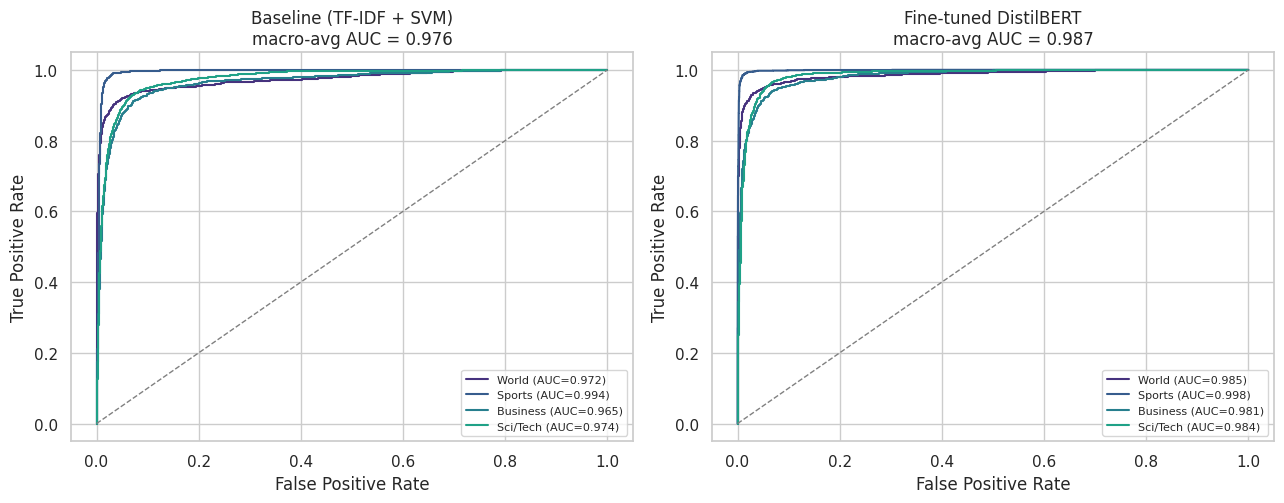

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from scipy.special import softmax

y_true_bin = label_binarize(test_frame[SETTINGS["label_col"]], classes=range(SETTINGS["n_labels"]))

svm_scores = baseline_clf.decision_function(test_frame[SETTINGS["text_col"]])
bert_probs = softmax(test_output.predictions, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, scores, title in [(axes[0], svm_scores, "Baseline (TF-IDF + SVM)"),
                           (axes[1], bert_probs, "Fine-tuned DistilBERT")]:
    aucs = []
    for i, label in enumerate(LABELS):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], scores[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        ax.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1)
    ax.set_title(f"{title}\nmacro-avg AUC = {np.mean(aucs):.3f}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. Is the difference statistically significant?

A higher macro-F1 could be noise. McNemar's test checks, on the *same* test examples, whether the pattern of "model A right / model B wrong" vs "model A wrong / model B right" is asymmetric enough to rule out chance (paired test, appropriate here because both models are scored on identical test rows).

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

y_test = test_frame[SETTINGS["label_col"]].to_numpy()
svm_correct = (svm_test_pred == y_test)
bert_correct = (bert_test_pred == y_test)

both_correct = int(np.sum(svm_correct & bert_correct))
only_svm = int(np.sum(svm_correct & ~bert_correct))
only_bert = int(np.sum(~svm_correct & bert_correct))
both_wrong = int(np.sum(~svm_correct & ~bert_correct))

table = [[both_correct, only_svm], [only_bert, both_wrong]]
show_table(pd.DataFrame(table,
                         index=["BERT correct", "BERT wrong"],
                         columns=["SVM correct", "SVM wrong"]))

result = mcnemar(table, exact=False, correction=True)
print(f"McNemar statistic = {result.statistic:.3f}, p-value = {result.pvalue:.6f}")
alpha = 0.05
verdict = "statistically significant" if result.pvalue < alpha else "NOT statistically significant"
print(f"At alpha={alpha}, the difference between models is {verdict}.")

|              |   SVM correct |   SVM wrong |
|--------------|---------------|-------------|
| BERT correct |     6680.0000 |    171.0000 |
| BERT wrong   |      327.0000 |    422.0000 |
McNemar statistic = 48.243, p-value = 0.000000
At alpha=0.05, the difference between models is statistically significant.


## 17. Efficiency: accuracy vs cost

A fair comparison reports cost as well as accuracy. This table/chart puts model size and speed next to the quality metrics so the trade-off is explicit, useful for the Discussion/Limitations section of your report.

| Model                 | Parameters   |   Train time (s) |   Predict time on test set (s) |   Rows/sec at inference |   Test accuracy |   Test macro-F1 |
|-----------------------|--------------|------------------|--------------------------------|-------------------------|-----------------|-----------------|
| TF-IDF + LinearSVC    |              |           1.8700 |                         0.4320 |              17592.1000 |          0.9014 |          0.9010 |
| Fine-tuned DistilBERT | 67.0M        |         325.3000 |                        12.9600 |                586.4000 |          0.9220 |          0.9220 |


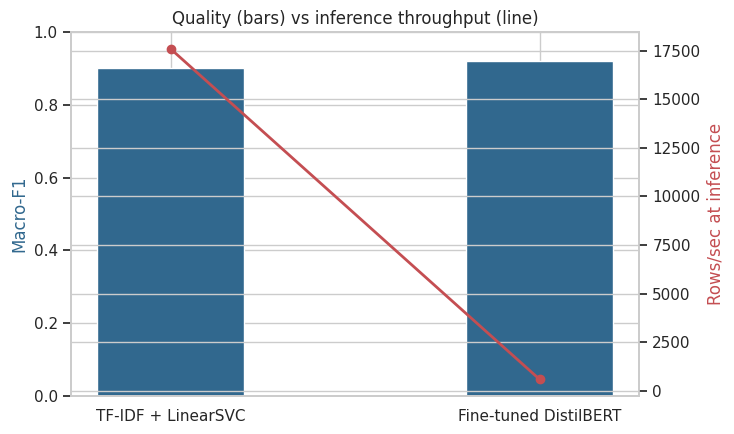

In [ ]:
bert_param_count = sum(p.numel() for p in model.parameters())

efficiency = pd.DataFrame({
    "Model": ["TF-IDF + LinearSVC", "Fine-tuned DistilBERT"],
    "Parameters": [None, f"{bert_param_count/1e6:.1f}M"],
    "Train time (s)": [round(svm_train_seconds, 2), round(bert_train_seconds, 1)],
    "Predict time on test set (s)": [round(svm_predict_seconds, 3), round(bert_predict_seconds, 2)],
    "Rows/sec at inference": [
        round(len(test_frame) / svm_predict_seconds, 1),
        round(len(test_frame) / bert_predict_seconds, 1),
    ],
    "Test accuracy": [baseline_scores["accuracy"], bert_scores["accuracy"]],
    "Test macro-F1": [baseline_scores["f1"], bert_scores["f1"]],
})
show_table(efficiency.set_index("Model"))
efficiency.to_csv(TAB_DIR / "efficiency_comparison.csv", index=False)

fig, ax1 = plt.subplots(figsize=(7.5, 4.5))
models_x = np.arange(2)
ax1.bar(models_x, efficiency["Test macro-F1"], width=0.4, color="#31688e", label="Test macro-F1")
ax1.set_ylabel("Macro-F1", color="#31688e")
ax1.set_ylim(0, 1)
ax1.set_xticks(models_x)
ax1.set_xticklabels(efficiency["Model"])

ax2 = ax1.twinx()
ax2.plot(models_x, efficiency["Rows/sec at inference"], color="#c44e52", marker="o",
         linewidth=2, label="Inference rows/sec")
ax2.set_ylabel("Rows/sec at inference", color="#c44e52")

ax1.set_title("Quality (bars) vs inference throughput (line)")
plt.tight_layout()
plt.savefig(FIG_DIR / "efficiency_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 18. Qualitative error analysis

Numbers alone don't explain *why* a model fails. This samples concrete articles where the two models disagree with each other or with the truth, useful evidence to quote directly in the Discussion section.

In [ ]:
test_view = test_frame.copy()
test_view["true_label"] = test_view[SETTINGS["label_col"]].map(lambda i: LABELS[i])
test_view["svm_pred"] = [LABELS[i] for i in svm_test_pred]
test_view["bert_pred"] = [LABELS[i] for i in bert_test_pred]

print("Examples BERT got right that the baseline got wrong (BERT\'s edge):")
bert_wins = test_view[(test_view["bert_pred"] == test_view["true_label"]) &
                       (test_view["svm_pred"] != test_view["true_label"])]
show_table(bert_wins[[SETTINGS["text_col"], "true_label", "svm_pred", "bert_pred"]].head(5), floatfmt="")

print("\nExamples BOTH models got wrong (genuinely hard cases):")
both_wrong_rows = test_view[(test_view["bert_pred"] != test_view["true_label"]) &
                             (test_view["svm_pred"] != test_view["true_label"])]
show_table(both_wrong_rows[[SETTINGS["text_col"], "true_label", "svm_pred", "bert_pred"]].head(5), floatfmt="")

Examples BERT got right that the baseline got wrong (BERT's edge):
|     | text                                                                                                                                                                                                                                                                                                                           | true_label   | svm_pred   | bert_pred   |
|-----|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------|------------|-------------|
|   3 | Prediction Unit Helps Forecast Wildfires (AP) AP - It's barely dawn when Mike Fitzpatrick starts his shift with a blur of colorful maps, figures and endless charts, but already he kno

In [ ]:
import os; os.listdir('outputs/figures')

['model_comparison_chart.png',
 'eda_balance_and_length.png',
 'efficiency_comparison.png',
 'confusion_matrices.png',
 'learning_curves.png',
 'per_class_metrics.png',
 'token_lengths.png',
 'roc_curves.png']

In [ ]:
import shutil
shutil.make_archive('all_figures', 'zip', 'outputs/figures')

'/content/all_figures.zip'